In [1]:
# import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score,average_precision_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Load data
df = pd.read_excel("02 Churn-Dataset.xlsx") 

In [3]:
# change TotalCharges to float and replacing null values with 0 as tenure is 0 for those rows so no charges.
df['TotalCharges'] = df['TotalCharges'].replace(" ", '0').astype(float)

In [4]:
# Target variable
y = df["Churn"].map({"Yes": 1, "No": 0})

# independent variables
X = df.drop(columns=["customerID", "Churn"])

In [5]:
# categorical_cols = [
#     "MultipleLines", "InternetService", "OnlineSecurity",
#     "OnlineBackup", "DeviceProtection", "TechSupport",
#     "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"
# ]
# numeric_cols = [
#     "SeniorCitizen", "tenure", "MonthlyCharges",
#     "TotalCharges", "numAdminTickets", "numTechTickets",
#     "gender", "Partner", "Dependents", "PhoneService",
#     "PaperlessBilling"
# ]

# Binary columns (object but only Yes/No)
binary_cols = [
    "gender", "Partner", "Dependents", "PhoneService",
    "PaperlessBilling"
]

binary_map = {
    "Yes": 1, "No": 0,
    "Male": 1, "Female": 0
}

In [6]:
# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [7]:
# Apply binary mapping 
for col in binary_cols:
    X_train[col] = X_train[col].map(binary_map).astype(int)
    X_test[col] = X_test[col].map(binary_map).astype(int)

categorical_cols = [col for col in X_train.columns if X_train[col].dtype == 'O']
numeric_cols = [col for col in X_train.columns if X_train[col].dtype != 'O']

# Column transformer 
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols),
        ("num", StandardScaler(),numeric_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)


feature_names = (
    preprocessor.named_transformers_["cat"]
    .get_feature_names_out(categorical_cols)
    .tolist()
    + numeric_cols
)

X_train_encoded = pd.DataFrame(X_train_encoded, columns=feature_names)

In [8]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1100, class_weight="balanced"))
    ]
)


In [9]:
#Hyperparameter Tuning 
# model1 = LogisticRegression(max_iter=1100,class_weight='balanced')
# penalty = ['l1','l2','elasticnet']
# c_values = [100,10,1.0,0,0.1,0.01]
# solver = ['newton-cg','lbfgs','liblinear','sag','saga']

param_grid = {
    "classifier__penalty": ["l1"],
    "classifier__C": [0.1],
    "classifier__solver": ["saga"]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [10]:
# GridSearchCV
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1
)


In [11]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1100))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1], 'classifier__penalty': ['l1'], 'classifier__solver': ['saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [12]:
y_pred = grid.predict(X_test)
y_probs = grid.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= 0.47).astype(int)

In [13]:
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_probs))
print("Average Precision Score:", average_precision_score(y_test, y_probs))

              precision    recall  f1-score   support

           0       0.95      0.80      0.87      1035
           1       0.62      0.89      0.73       374

    accuracy                           0.82      1409
   macro avg       0.78      0.85      0.80      1409
weighted avg       0.86      0.82      0.83      1409

Accuracy: 0.8239886444286728
ROC AUC Score: 0.9272029760520809
Average Precision Score: 0.825294097436136


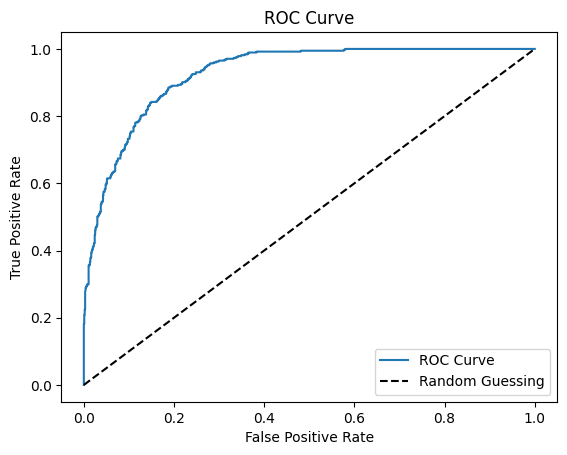

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [14]:
import joblib

joblib.dump(grid.best_estimator_, "churn_model.pkl")

['churn_model.pkl']